In [ ]:
#|default_exp app

# Electronic Component Recognizer

This project is an end-to-end pipeline for building an image classification system that can recognize and classify electronic components. It covers the entire workflow — from **data collection, data cleaning, training, evaluation, and deployment** to **API integration with a live demo**.

The model is designed to classify **20 different types of commonly used electronic components** in circuits, prototyping, and hardware systems.

### Supported Component Classes

1. Resistor
2. Capacitor
3. Diode
4. Transistor
5. IC Chip
6. Relay
7. Switch
8. Transformer
9. LED
10. Connector
11. Potentiometer
12. Fuse
13. Inductor Coil
14. Crystal Oscillator
15. Heat Sink
16. Breadboard
17. Jumper Wire
18. Battery Holder
19. Power Supply Module
20. Microcontroller Board


In [ ]:
!pip install -Uqq fastai gradio nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.8 MB/s eta 0:00:00


In [ ]:
from fastai.vision.all import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/datasets

/content/drive/My Drive/datasets


In [ ]:
#!export
from fastai.vision.all import load_learner
import gradio as gr

In [ ]:
#!export
model = load_learner('models/component-recognizer-v3.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
electronic_labels = [
    "resistor",
    "capacitor",
    "diode",
    "transistor",
    "ic chip",
    "relay",
    "switch",
    "transformer",
    "led",
    "connector",
    "potentiometer",
    "fuse",
    "inductor coil",
    "crystal oscillator",
    "heat sink",
    "breadboard",
    "jumper wire",
    "battery holder",
    "power supply module",
    "microcontroller board"
]

def recognize_image(image):
  pred, idx, probs = model.predict(image)
  return dict(zip(electronic_labels, map(float, probs)))


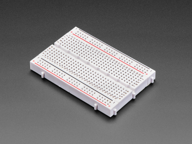

In [ ]:
img = PILImage.create(f'test-images/Breadboard.jpg')
img.thumbnail((192,192))
img

In [ ]:
recognize_image(img)

{'resistor': 1.1008724868588615e-05,
 'capacitor': 0.9991220831871033,
 'diode': 1.971599658645573e-06,
 'transistor': 2.181000127166044e-05,
 'ic chip': 0.00010360906890127808,
 'relay': 3.9815706287527064e-08,
 'switch': 3.345329332660185e-06,
 'transformer': 5.250481626717374e-05,
 'led': 1.5151873412833083e-05,
 'connector': 2.8287699024076574e-05,
 'potentiometer': 0.00016001303447410464,
 'fuse': 3.3372245411555923e-07,
 'inductor coil': 0.00022290415654424578,
 'crystal oscillator': 8.126789907692e-06,
 'heat sink': 6.726890569552779e-05,
 'breadboard': 0.0001556976931169629,
 'jumper wire': 9.88251940725604e-06,
 'battery holder': 4.421329776960192e-06,
 'power supply module': 3.232419658161234e-06,
 'microcontroller board': 8.163882739609107e-06}

In [ ]:
import gradio as gr

image = gr.Image(type="numpy", height=192, width=192)
label = gr.Label()

examples = [
    'test-images/Breadboard.jpg',
    'test-images/ic-chip.png',
    'test-images/battery holder.jpg',
    'test-images/diod.png',
    'test-images/transistor.jpg',
    'test-images/connector.webp',

]

iface = gr.Interface(
    fn=recognize_image,
    inputs=image,
    outputs=label,
    examples=examples
)

iface.launch(inline=False, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9de957b2f9a381f61c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# New Section

# Notebook to Python Script Export